In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0 — One-time setup
# ══════════════════════════════════════════════════════════════════════════════
#
# HOW TO USE:
#   • First time on a fresh runtime: run this cell. It installs packages
#     and restarts the kernel. Then skip to Cell 1.
#   • If Cell 2 still shows numpy 1.26.4 after restart:
#     → Runtime menu > "Disconnect and delete runtime" → reconnect → run again.
#   • Never run this cell a second time in the same session.
# ══════════════════════════════════════════════════════════════════════════════

import subprocess, sys, os

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip"] + list(args),
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# ── Check current numpy ──────────────────────────────────────────────────────
try:
    import numpy as _np
    _cur = tuple(int(x) for x in _np.__version__.split(".")[:2])
except Exception:
    _cur = (0, 0)

if _cur >= (2, 0):
    print(f"numpy {_np.__version__} already OK — skipping reinstall.")
else:
    print(f"numpy {_np.__version__} is too old — upgrading...")
    # Uninstall first so pip doesn't leave stale .dist-info confusing things
    subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "numpy"],
                    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    pip("install", "-q", "numpy>=2.0,<2.6")
    import importlib
    _np = importlib.import_module("numpy")
    print(f"numpy {_np.__version__} installed.")

# ── All other packages ───────────────────────────────────────────────────────
pip("install", "-q", "transformers", "accelerate", "huggingface_hub", "datasets")
pip("install", "-q", "open3d", "matplotlib", "tqdm", "einops", "h5py",
                     "scipy", "scikit-learn", "Pillow", "pandas")

r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "faiss-gpu-cu12"],
                   capture_output=True)
if r.returncode != 0:
    pip("install", "-q", "faiss-cpu")
    print("faiss-cpu installed (fallback)")
else:
    print("faiss-gpu-cu12 installed")

if not os.path.exists("/content/vggt_repo/vggt"):
    subprocess.check_call(["git", "clone",
        "https://github.com/facebookresearch/vggt.git",
        "/content/vggt_repo", "--quiet"])
pip("install", "-q", "-e", "/content/vggt_repo")

print("\n✅ All packages installed.")
print("⚡ Restarting kernel — after restart, SKIP this cell and start from Cell 1.")

import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)


numpy 2.0.2 already OK — skipping reinstall.
faiss-gpu-cu12 installed

✅ All packages installed.
⚡ Restarting kernel — after restart, SKIP this cell and start from Cell 1.


{'status': 'ok', 'restart': True}

In [1]:
import subprocess
info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(info.stdout)
print('✅ A100 confirmed.' if 'A100' in info.stdout else
      '⚠️  A100 not found — go to Runtime > Change runtime type > A100 GPU.')

Sat Apr  4 22:03:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import sys, os, json, time, random, zipfile, datetime
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import faiss

sys.path.insert(0, '/content/vggt_repo')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.bfloat16 if (torch.cuda.is_available() and
         torch.cuda.get_device_capability()[0] >= 8) else torch.float16

print(f'Device : {DEVICE}')
print(f'DType  : {DTYPE}  (bfloat16 on Ampere / A100)')
print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Device : cuda
DType  : torch.bfloat16  (bfloat16 on Ampere / A100)
PyTorch: 2.10.0+cu128


In [4]:
ROOT        = Path('/content/vggt_nyc')
DATA_DIR    = ROOT / 'data' / 'nyc_indoor_vpr'
RESULTS_DIR = ROOT / 'results'
MODELS_DIR  = ROOT / 'models'
VIS_DIR     = ROOT / 'visualizations'
for d in [DATA_DIR, RESULTS_DIR, MODELS_DIR, VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('✅ Directories ready')

✅ Directories ready


# Dataset Download, Extraction

In [5]:
from huggingface_hub import snapshot_download

zip_path = DATA_DIR / 'indoor_anony1.zip'
csv_path = DATA_DIR / 'indoor_anony_metadata.csv'

if zip_path.exists() and csv_path.exists():
    print('✅ Dataset already downloaded.')
else:
    print('Downloading NYC-Indoor-VPR (~38 GB) ...')
    snapshot_download(
        repo_id='ai4ce/NYC-Indoor-VPR-Data',
        repo_type='dataset',
        local_dir=str(DATA_DIR),
        ignore_patterns=['*.git*'],
    )
    print('✅ Download complete.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Download complete.


In [6]:
anony_dir = DATA_DIR / 'indoor_anony'

if anony_dir.exists() and any(anony_dir.rglob('*.jpg')):
    n = len(list(anony_dir.rglob('*.jpg')))
    print(f'✅ Already extracted: {n:,} images.')
else:
    print(f'Extracting indoor_anony1.zip ...')
    with zipfile.ZipFile(DATA_DIR / 'indoor_anony1.zip', 'r') as zf:
        print(f'  {len(zf.namelist()):,} files in archive')
        zf.extractall(DATA_DIR)
    print(f'✅ Done — {len(list(anony_dir.rglob("*.jpg"))):,} images extracted.')

Extracting indoor_anony1.zip ...
  36,117 files in archive
✅ Done — 36,107 images extracted.


In [7]:
df = pd.read_csv(DATA_DIR / 'indoor_anony_metadata.csv')
df['full_path'] = df['path'].apply(lambda p: DATA_DIR / p)

print(f'Rows: {len(df):,}  |  Scenes: {df["scene"].nunique()}')
print()
print('Split × Category:')
print(df.groupby(['split','category']).size().unstack(fill_value=0))
print()
print('Images per scene:')
print(df.groupby('scene').size().sort_values(ascending=False).to_string())

Rows: 34,777  |  Scenes: 20

Split × Category:
category  database  queries
split                      
test          1939     1880
train        15601     7630
val           3941     3786

Images per scene:
scene
World Trade Center             11890
Fulton Subway Station           3536
Bobst Library basement          3418
Bobst Library 5th floor         3410
Morton Williams Supermarket     2778
Bobst Library 4th floor         2231
Silver Center 2nd floor         1571
Silver Center 4th floor          943
Silver Center 5th floor          878
The Met 2nd region               700
Silver Center 9th floor          629
Silver Center 3rd floor          575
Silver Center 6th floor          563
The Met 4th region               406
The Met 5th region               300
The Met 7th region               252
The Met 1st region               245
The Met 8th region               208
The Met 6th region               172
The Met 3rd region                72


In [8]:
sample = df.sample(10, random_state=SEED)
ok = all(Path(r['full_path']).exists() for _, r in sample.iterrows())
for _, r in sample.iterrows():
    e = Path(r['full_path']).exists()
    print(f'  {"✅" if e else "❌"}  {r["path"]}')
print('\n✅ All paths verified.' if ok else '\n❌ Some paths missing — check extraction.')

  ✅  indoor_anony/train/database/@18029.38@00021.34@533@.jpg
  ✅  indoor_anony/train/database/@08056.70@00070.57@6122@.jpg
  ✅  indoor_anony/val/database/@02084.24@00005.40@105@.jpg
  ✅  indoor_anony/train/queries/@08016.65@00075.44@5562@.jpg
  ✅  indoor_anony/test/queries/@07001.45@00024.33@242@.jpg
  ✅  indoor_anony/train/queries/@08058.11@00092.13@2832@.jpg
  ✅  indoor_anony/val/queries/@08163.74@00166.68@1806@.jpg
  ✅  indoor_anony/train/database/@08058.34@00021.85@8955@.jpg
  ✅  indoor_anony/train/queries/@02116.59@00002.93@140@.jpg
  ✅  indoor_anony/train/queries/@08084.07@00078.73@5374@.jpg

✅ All paths verified.


In [9]:
def build_splits(df):
    splits = {}
    print(f'{"Split":<6} {"Role":<10} {"Images":>8} {"Scenes":>8}')
    print('-'*36)
    for sp in ['train','val','test']:
        for cat, suf in [('database','db'),('queries','query')]:
            sub = df[(df['split']==sp)&(df['category']==cat)].reset_index(drop=True)
            splits[f'{sp}_{suf}'] = sub
            print(f'{sp:<6} {suf:<10} {len(sub):>8,} {sub["scene"].nunique():>8}')
    return splits

splits      = build_splits(df)
train_db    = splits['train_db']
train_query = splits['train_query']
val_db      = splits['val_db']
val_query   = splits['val_query']
test_db     = splits['test_db']     # ← final evaluation
test_query  = splits['test_query']  # ← final evaluation
print(f'\nFinal eval: {len(test_db):,} DB  |  {len(test_query):,} queries')

Split  Role         Images   Scenes
------------------------------------
train  db           15,601       20
train  query         7,630       20
val    db            3,941       20
val    query         3,786       20
test   db            1,939        9
test   query         1,880        9

Final eval: 1,939 DB  |  1,880 queries


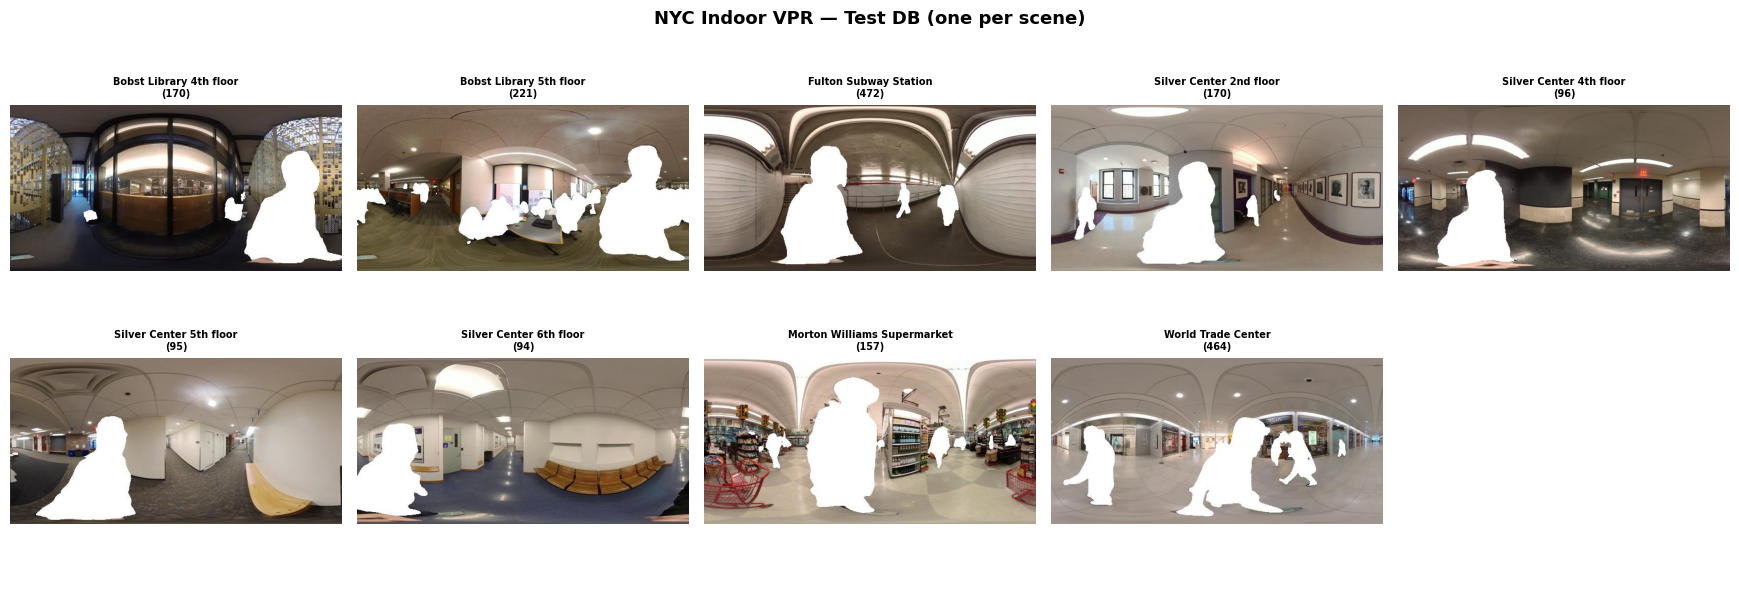

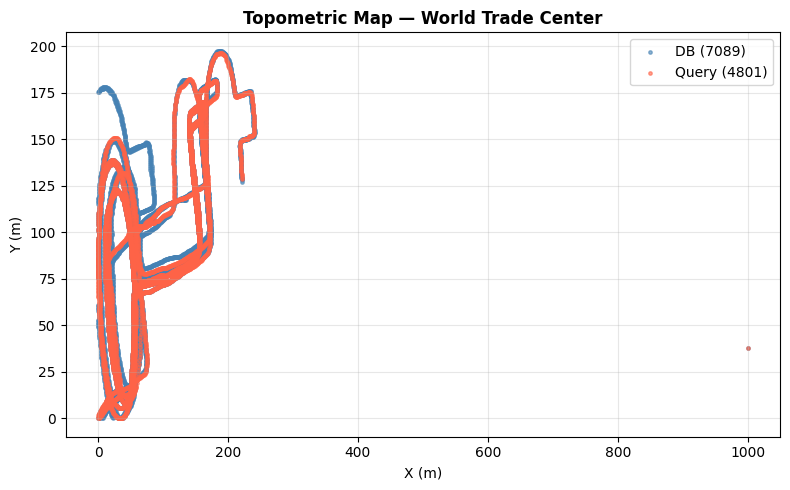

In [10]:
def show_scene_samples(split_df, title=''):
    scenes = split_df['scene'].unique()
    cols   = 5
    rows   = (len(scenes) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*3))
    axes = np.array(axes).flatten()
    for i, scene in enumerate(scenes):
        sub = split_df[split_df['scene']==scene]
        row = sub.iloc[len(sub)//2]
        try:    axes[i].imshow(Image.open(row['full_path']).convert('RGB'))
        except: axes[i].set_facecolor('lightgray')
        axes[i].set_title(f'{scene}\n({len(sub)})', fontsize=7, fontweight='bold')
        axes[i].axis('off')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(VIS_DIR/f'{title.replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

def plot_scene_trajectory(df, scene):
    sub  = df[df['scene']==scene]
    db_  = sub[sub['category']=='database']
    q_   = sub[sub['category']=='queries']
    fig, ax = plt.subplots(figsize=(8,5))
    ax.scatter(db_['x'], db_['y'], c='steelblue', s=6, alpha=0.6, label=f'DB ({len(db_)})')
    ax.scatter(q_['x'],  q_['y'],  c='tomato',    s=6, alpha=0.6, label=f'Query ({len(q_)})')
    ax.set_title(f'Topometric Map — {scene}', fontweight='bold')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(VIS_DIR/f'traj_{scene[:20].replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

show_scene_samples(test_db, 'NYC Indoor VPR — Test DB (one per scene)')
plot_scene_trajectory(df, df.groupby('scene').size().idxmax())

# DINOv2

In [11]:
from transformers import AutoImageProcessor, AutoModel

class DINOv2Retrieval:
    def __init__(self, model_name='facebook/dinov2-base', device=DEVICE):
        print(f'Loading DINOv2 ({model_name}) ...')
        self.processor = AutoImageProcessor.from_pretrained(model_name)
        self.model     = AutoModel.from_pretrained(model_name).to(device)
        self.model.eval()
        self.device = device
        self.index  = None
        self.db_df  = None
        print('✅ DINOv2 loaded.')

    @torch.no_grad()
    def embed_images(self, paths, batch_size=64, desc='Embedding'):
        all_embs = []
        for i in tqdm(range(0, len(paths), batch_size), desc=desc):
            batch = paths[i:i+batch_size]
            imgs  = []
            for p in batch:
                try:    imgs.append(Image.open(p).convert('RGB'))
                except: imgs.append(Image.new('RGB',(224,224),128))
            inputs  = self.processor(images=imgs, return_tensors='pt').to(self.device)
            cls_emb = self.model(**inputs).last_hidden_state[:,0,:]
            cls_emb = F.normalize(cls_emb, dim=-1)
            all_embs.append(cls_emb.cpu().float().numpy())
        return np.vstack(all_embs)

    def build_index(self, db_df, cache_prefix='test_db'):
        c_emb = MODELS_DIR/f'{cache_prefix}_embs.npy'
        c_idx = MODELS_DIR/f'{cache_prefix}_faiss.index'
        if c_emb.exists() and c_idx.exists():
            print(f'Loading cached index ({cache_prefix}) ...')
            embs       = np.load(c_emb)
            self.index = faiss.read_index(str(c_idx))
            self.db_df = db_df.reset_index(drop=True)
            print(f'✅ {self.index.ntotal:,} vectors, dim={embs.shape[1]}')
            return
        print(f'Building index for {len(db_df):,} images ...')
        embs = self.embed_images(db_df['full_path'].tolist(), desc='DB index')
        self.index = faiss.IndexFlatIP(embs.shape[1])
        self.index.add(embs.astype(np.float32))
        self.db_df = db_df.reset_index(drop=True)
        np.save(c_emb, embs)
        faiss.write_index(self.index, str(c_idx))
        print(f'✅ Built & cached: {self.index.ntotal:,} vectors')

    def retrieve_batch(self, query_df, top_k=25, batch_size=64):
        paths  = query_df['full_path'].tolist()
        q_embs = self.embed_images(paths, batch_size=batch_size, desc='Query embed')
        scores, idxs = self.index.search(q_embs.astype(np.float32), top_k)
        return [
            [(self.db_df.iloc[idx], float(scores[i][j]))
             for j, idx in enumerate(idxs[i]) if idx < len(self.db_df)]
            for i in range(len(query_df))
        ]

retrieval_model = DINOv2Retrieval()
retrieval_model.build_index(test_db, cache_prefix='test_db')

Loading DINOv2 (facebook/dinov2-base) ...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

✅ DINOv2 loaded.
Building index for 1,939 images ...


DB index: 100%|██████████| 31/31 [00:13<00:00,  2.28it/s]

✅ Built & cached: 1,939 vectors


Query embed: 100%|██████████| 1/1 [00:00<00:00,  8.64it/s]


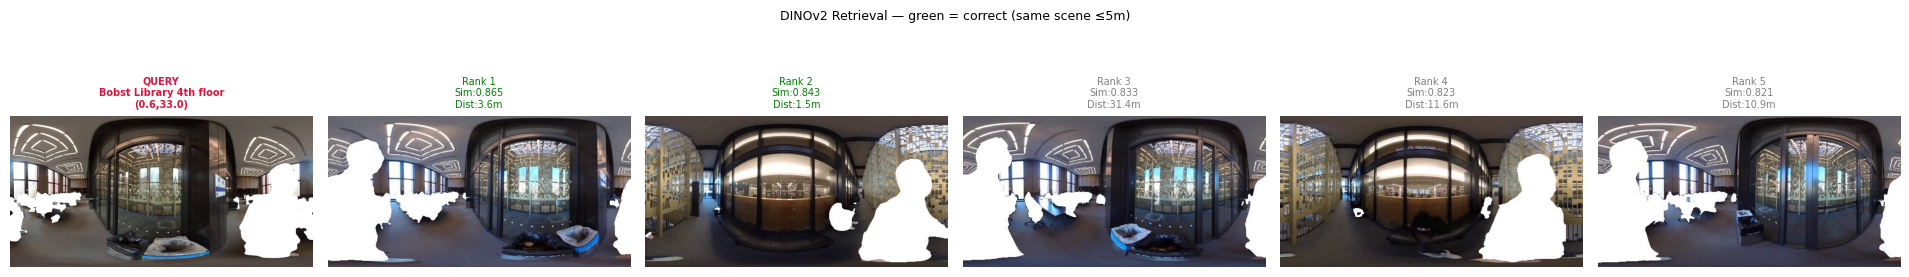

Query embed: 100%|██████████| 1/1 [00:00<00:00, 15.60it/s]


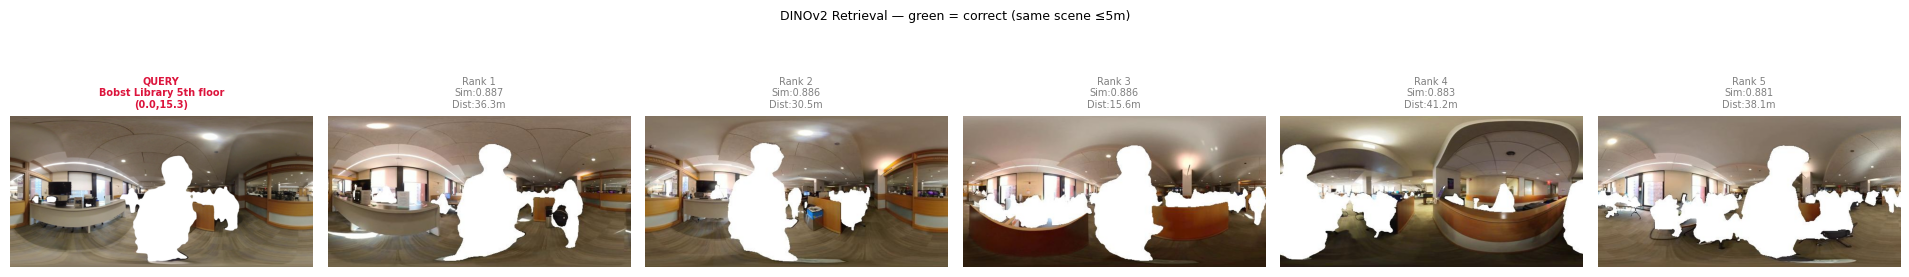

Query embed: 100%|██████████| 1/1 [00:00<00:00, 13.24it/s]


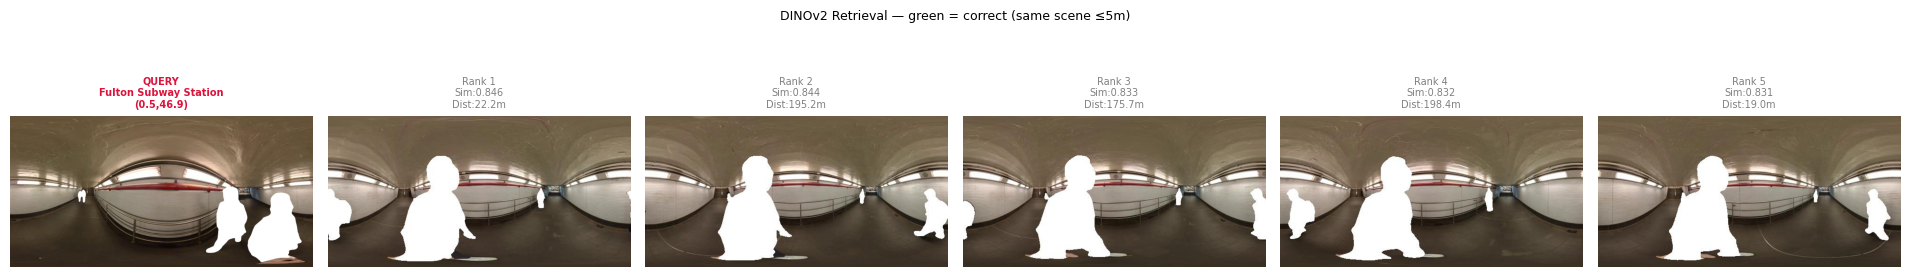

In [12]:
def visualize_retrieval(q_row, retrieved, n_show=5, save_name='retrieval.png'):
    n = min(n_show, len(retrieved)) + 1
    fig, axes = plt.subplots(1, n, figsize=(n*3.2, 3.5))
    axes[0].imshow(Image.open(q_row['full_path']).convert('RGB'))
    axes[0].set_title(f'QUERY\n{q_row["scene"]}\n({q_row["x"]:.1f},{q_row["y"]:.1f})',
                      fontweight='bold', color='crimson', fontsize=7)
    axes[0].axis('off')
    for i,(db_row,score) in enumerate(retrieved[:n_show]):
        dist  = np.sqrt((db_row['x']-q_row['x'])**2+(db_row['y']-q_row['y'])**2)
        color = 'green' if (db_row['scene']==q_row['scene'] and dist<=5) else 'gray'
        try:   axes[i+1].imshow(Image.open(db_row['full_path']).convert('RGB'))
        except: pass
        axes[i+1].set_title(f'Rank {i+1}\nSim:{score:.3f}\nDist:{dist:.1f}m',
                             fontsize=7, color=color)
        axes[i+1].axis('off')
    plt.suptitle('DINOv2 Retrieval — green = correct (same scene ≤5m)', fontsize=9)
    plt.tight_layout()
    plt.savefig(VIS_DIR/save_name, dpi=100, bbox_inches='tight')
    plt.show()

# Demo on first query of each scene
for scene in list(test_query['scene'].unique())[:3]:
    q_row = test_query[test_query['scene']==scene].iloc[0]
    ret   = retrieval_model.retrieve_batch(
                q_row.to_frame().T.reset_index(drop=True), top_k=5)[0]
    visualize_retrieval(q_row, ret,
                        save_name=f'retrieval_{scene[:12].replace(" ","_")}.png')

# Evaluation

In [13]:
DIST_THRESHOLDS = [3, 5, 10]
K_VALUES        = [1, 5, 10, 25]

def topo_dist(q, db):
    return float(np.sqrt((q['x']-db['x'])**2+(q['y']-db['y'])**2))

def compute_recall(query_df, all_retrieved,
                   k_values=K_VALUES, dist_thresholds=DIST_THRESHOLDS):
    n      = len(query_df)
    recall = {d:{k:0 for k in k_values} for d in dist_thresholds}
    for i,(_, q) in enumerate(query_df.iterrows()):
        ret = all_retrieved[i]
        for d in dist_thresholds:
            for k in k_values:
                if any(db['scene']==q['scene'] and topo_dist(q,db)<=d
                       for db,_ in ret[:k]):
                    recall[d][k] += 1
    for d in dist_thresholds:
        for k in k_values:
            recall[d][k] = 100.0*recall[d][k]/n
    return recall

def compute_per_scene_recall(query_df, all_retrieved,
                              k_values=K_VALUES, dist_thresholds=DIST_THRESHOLDS):
    qdf = query_df.reset_index(drop=True)
    out = {}
    for scene in qdf['scene'].unique():
        mask = qdf['scene']==scene
        idxs = mask[mask].index.tolist()
        out[scene] = compute_recall(
            qdf.loc[idxs], [all_retrieved[i] for i in idxs],
            k_values, dist_thresholds
        )
    return out

def print_recall_table(recall, condition=''):
    w = 8
    hdr = f"{'Threshold':<13}" + ''.join(f"{'R@'+str(k):>{w}}" for k in K_VALUES)
    print(f'\n📊 {condition}')
    print('='*len(hdr))
    print(hdr)
    print('-'*len(hdr))
    for d in DIST_THRESHOLDS:
        print(f'≤{d}m{"":<10}' + ''.join(f"{recall[d][k]:>{w}.1f}" for k in K_VALUES))
    print('='*len(hdr))

print('Evaluation functions ready.')

Evaluation functions ready.


In [14]:
# ── Condition A: DINOv2 Zero-Shot Retrieval ───────────────────────
print(f'Condition A: {len(test_query):,} queries | {len(test_db):,} DB | top-K=25')

retrieved_A = retrieval_model.retrieve_batch(test_query, top_k=25)
recall_A    = compute_recall(test_query.reset_index(drop=True), retrieved_A)
per_scene_A = compute_per_scene_recall(test_query.reset_index(drop=True), retrieved_A)

print_recall_table(recall_A, 'Condition A — DINOv2 Zero-Shot')

with open(RESULTS_DIR/'recall_A.json','w') as f:
    json.dump({'condition':'DINOv2_zeroshot','recall':recall_A,
               'n_queries':len(test_query)}, f, indent=2)
print('Saved.')

Condition A: 1,880 queries | 1,939 DB | top-K=25


Query embed: 100%|██████████| 30/30 [01:36<00:00,  3.23s/it]



📊 Condition A — DINOv2 Zero-Shot
Threshold         R@1     R@5    R@10    R@25
---------------------------------------------
≤3m               7.3    26.9    38.2    54.0
≤5m              10.7    38.1    52.3    72.2
≤10m              17.5    54.8    72.7    91.3
Saved.


In [15]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [16]:
from google.colab import output
output.disable_custom_widget_manager()

# VGGT

In [17]:
from vggt.models.vggt import VGGT
from vggt.utils.load_fn import load_and_preprocess_images
from vggt.utils.pose_enc import pose_encoding_to_extri_intri
from vggt.utils.geometry import unproject_depth_map_to_point_map

print('Loading VGGT-1B (auto-downloads weights on first run ~2.4 GB) ...')
vggt_model = VGGT.from_pretrained('facebook/VGGT-1B').to(DEVICE)
vggt_model.eval()
print(f'✅ VGGT-1B loaded.')
print(f'   Parameters: {sum(p.numel() for p in vggt_model.parameters()):,}')

Loading VGGT-1B (auto-downloads weights on first run ~2.4 GB) ...


config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.03G [00:00<?, ?B/s]

✅ VGGT-1B loaded.
   Parameters: 1,256,537,516


In [18]:
# ── Smoke test — verify shapes and output keys ────────────────────
sample_paths = [
    str(test_db.iloc[0]['full_path']),
    str(test_db.iloc[1]['full_path']),
]

images_test = load_and_preprocess_images(sample_paths).to(DEVICE)
print(f'Input shape: {images_test.shape}  (S, 3, H, W)')

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=DTYPE):
        preds_test = vggt_model(images_test)

print('\nOutput keys and shapes:')
for k, v in preds_test.items():
    shape = v.shape if hasattr(v,'shape') else type(v)
    print(f'  {k}: {shape}')

ext_test, int_test = pose_encoding_to_extri_intri(
    preds_test['pose_enc'], images_test.shape[-2:])
print(f'\nextrinsic: {ext_test.shape}  (S, 3, 4)')
print(f'intrinsic: {int_test.shape}  (S, 3, 3)')
print('✅ VGGT API confirmed.')

Input shape: torch.Size([2, 3, 252, 518])  (S, 3, H, W)


/tmp/ipykernel_2390/3394190251.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=DTYPE):
/content/vggt_repo/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):



Output keys and shapes:
  pose_enc: torch.Size([1, 2, 9])
  pose_enc_list: <class 'list'>
  depth: torch.Size([1, 2, 252, 518, 1])
  depth_conf: torch.Size([1, 2, 252, 518])
  world_points: torch.Size([1, 2, 252, 518, 3])
  world_points_conf: torch.Size([1, 2, 252, 518])
  images: torch.Size([1, 2, 3, 252, 518])

extrinsic: torch.Size([1, 2, 3, 4])  (S, 3, 4)
intrinsic: torch.Size([1, 2, 3, 3])  (S, 3, 3)
✅ VGGT API confirmed.


In [19]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [20]:
from google.colab import output
output.disable_custom_widget_manager()

In [21]:
@torch.no_grad()
def run_vggt(image_paths: list) -> dict:
    images = load_and_preprocess_images(image_paths).to(DEVICE)

    with torch.amp.autocast('cuda', dtype=DTYPE):
        preds = vggt_model(images)

    extrinsic, intrinsic = pose_encoding_to_extri_intri(
        preds['pose_enc'], images.shape[-2:]
    )

    extrinsic = extrinsic[0]   # (S, 3, 4)
    intrinsic = intrinsic[0]   # (S, 3, 3)

    return {
        'extrinsic': extrinsic.cpu().float().numpy(),
        'intrinsic': intrinsic.cpu().float().numpy(),
        'depth': preds['depth'][0].cpu().float().numpy(),
        'depth_conf': preds['depth_conf'][0].cpu().float().numpy(),
        'world_points': preds['world_points'][0].cpu().float().numpy(),
        'world_points_conf': preds['world_points_conf'][0].cpu().float().numpy(),
    }


@torch.no_grad()
def vggt_geometric_score(q_path: str, db_path: str, verbose: bool = False) -> float:
    try:
        out = run_vggt([q_path, db_path])
        extr = out['extrinsic']   # (2, 3, 4)

        t0 = extr[0, :, 3]
        t1 = extr[1, :, 3]

        t_rel = np.linalg.norm(t0 - t1)
        score = float(-t_rel)

        if verbose:
            print(f't0={t0}, t1={t1}, t_rel={t_rel:.4f}, geo={score:.4f}')

        return score

    except Exception as e:
        print(f'VGGT scoring failed:\n  query={q_path}\n  db={db_path}\n  error={e}')
        return 0.0


def _minmax(vals):
    vals = np.asarray(vals, dtype=np.float32)
    if len(vals) == 0:
        return vals
    vmin, vmax = vals.min(), vals.max()
    if abs(vmax - vmin) < 1e-8:
        return np.ones_like(vals) * 0.5
    return (vals - vmin) / (vmax - vmin)


def vggt_rerank(q_row, candidates, top_k_rerank=10, alpha=0.5, verbose=False):
    """
    Re-rank top-k DINOv2 candidates using normalized retrieval + VGGT geometry.
    """
    pool = candidates[:top_k_rerank]
    rest = candidates[top_k_rerank:]

    db_rows = []
    ret_scores = []
    geo_scores = []

    for db_row, ret_score in pool:
        geo = vggt_geometric_score(
            str(q_row['full_path']),
            str(db_row['full_path']),
            verbose=False
        )
        db_rows.append(db_row)
        ret_scores.append(float(ret_score))
        geo_scores.append(float(geo))

    ret_norm = _minmax(ret_scores)
    geo_norm = _minmax(geo_scores)

    scored = []
    for rank, db_row in enumerate(db_rows, start=1):
        combined = alpha * ret_norm[rank - 1] + (1 - alpha) * geo_norm[rank - 1]
        scored.append((db_row, float(combined)))

        if verbose:
            print(
                f'Rank {rank:02d} | ret={ret_scores[rank-1]:.4f} | geo={geo_scores[rank-1]:.4f} | '
                f'ret_n={ret_norm[rank-1]:.4f} | geo_n={geo_norm[rank-1]:.4f} | combined={combined:.4f}'
            )

    scored.sort(key=lambda x: x[1], reverse=True)
    return scored + rest


In [22]:
#── Condition B ──

retrieved_B = []
test_query_r = test_query.reset_index(drop=True)
changed = 0

for i, (_, q_row) in enumerate(tqdm(test_query_r.iterrows(),
                                     total=len(test_query_r),
                                     desc='VGGT Re-ranking')):
    reranked = vggt_rerank(q_row, retrieved_A[i], top_k_rerank=10, alpha=0.5)
    retrieved_B.append(reranked)

    old_top10 = [str(x[0]['full_path']) for x in retrieved_A[i][:10]]
    new_top10 = [str(x[0]['full_path']) for x in reranked[:10]]
    if old_top10 != new_top10:
        changed += 1

print(f'Queries with changed top-10 order: {changed}/{len(test_query_r)}')

recall_B = compute_recall(test_query_r, retrieved_B)
per_scene_B = compute_per_scene_recall(test_query_r, retrieved_B)

print_recall_table(recall_B, 'Condition B — VGGT Geometric Re-Ranking')

with open(RESULTS_DIR/'recall_B.json', 'w') as f:
    json.dump({
        'condition': 'VGGT_reranked',
        'recall': recall_B,
        'changed_top10_queries': changed
    }, f, indent=2)

print('Saved.')

VGGT Re-ranking: 100%|██████████| 1880/1880 [1:07:15<00:00,  2.15s/it]


Queries with changed top-10 order: 1879/1880

📊 Condition B — VGGT Geometric Re-Ranking
Threshold         R@1     R@5    R@10    R@25
---------------------------------------------
≤3m               7.3    25.6    38.2    54.0
≤5m              11.1    36.6    52.3    72.2
≤10m              18.0    55.2    72.7    91.3
Saved.


# Fine Tuning VGGT

In [23]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

# ── Knobs ──────────────────────────────────────────────────────────────────
FT_BATCH_SIZE  = 16   # triplets per step  (raise to 24 if no OOM)
FT_GRAD_ACCUM  = 2    # effective batch = FT_BATCH_SIZE * FT_GRAD_ACCUM = 32
FT_EPOCHS      = 2    # 2 epochs w/ larger eff. batch ≈ original 3 epochs
FT_LR          = 5e-6
FT_MARGIN      = 0.3
FT_NUM_WORKERS = 4    # raise to 6-8 if Colab allows

# ── Fast image transform (replaces load_and_preprocess_images in __getitem__)
# VGGT pretrained at 518×518 with ImageNet normalisation.
_VGGT_TRANSFORM = T.Compose([
    T.Resize((518, 518), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

def _load_img(path):
    try:
        from PIL import Image as _PIL
        return _VGGT_TRANSFORM(_PIL.open(path).convert('RGB'))
    except Exception:
        return torch.zeros(3, 518, 518)


class NYCTripletDataset(Dataset):
    """
    Triplet dataset.
    __getitem__ uses a lightweight PIL+torchvision pipeline instead of
    load_and_preprocess_images, so DataLoader workers are not bottlenecked
    by VGGT's heavier inference utility.
    """
    def __init__(self, db_df, pos_dist=3.0, neg_dist=10.0, max_per=3):
        self.triplets = []
        for scene, grp in db_df.groupby('scene'):
            grp    = grp.reset_index(drop=True)
            coords = grp[['x','y']].values
            for i in range(len(grp)):
                dists   = np.linalg.norm(coords - coords[i], axis=1)
                pos_idx = np.where((dists>0.1)&(dists<=pos_dist))[0]
                neg_idx = np.where(dists>neg_dist)[0]
                if len(pos_idx)==0 or len(neg_idx)==0: continue
                for _ in range(min(max_per, len(pos_idx))):
                    p = grp.iloc[random.choice(pos_idx)]
                    n = grp.iloc[random.choice(neg_idx)]
                    self.triplets.append((
                        str(grp.iloc[i]['full_path']),
                        str(p['full_path']),
                        str(n['full_path']),
                    ))
        print(f'Triplets: {len(self.triplets):,} from {len(db_df):,} images')

    def __len__(self): return len(self.triplets)

    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return _load_img(a), _load_img(p), _load_img(n)


ft_dataset = NYCTripletDataset(train_db)
ft_loader  = DataLoader(
    ft_dataset,
    batch_size         = FT_BATCH_SIZE,
    shuffle            = True,
    num_workers        = FT_NUM_WORKERS,
    pin_memory         = True,
    drop_last          = True,
    persistent_workers = True,   # workers stay alive between epochs
    prefetch_factor    = 2,      # pre-fetch 2 batches per worker
)
print(f'DataLoader: {len(ft_loader)} batches/epoch  '
      f'(eff. batch = {FT_BATCH_SIZE * FT_GRAD_ACCUM} with grad accum)')


Triplets: 46,661 from 15,601 images
DataLoader: 2916 batches/epoch  (eff. batch = 32 with grad accum)


In [34]:
def get_vggt_embedding(imgs_3hw: torch.Tensor, model) -> torch.Tensor:
    """
    Extract a normalized global descriptor from VGGT for a batch of single images.

    imgs_3hw : (B, 3, H, W)
    Returns  : (B, D) float32 on DEVICE, L2-normalized

    Important:
    VGGT aggregator expects (B, S, 3, H, W), so we add S=1.
    """
    imgs = imgs_3hw.to(DEVICE, non_blocking=True)
    imgs = imgs.unsqueeze(1).to(dtype=DTYPE)   # (B, 1, 3, H, W)

    agg_tokens, _ = model.aggregator(imgs)

    last = agg_tokens[-1]              # expected shape: (B, seq, D)
    emb = last.mean(dim=1).float()     # (B, D)
    emb = F.normalize(emb, p=2, dim=-1)
    return emb


def finetune_vggt(
    model,
    train_loader,
    val_query_df,
    val_retrieval_model,
    n_epochs=3,
    lr=5e-6,
    margin=0.3,
    save_path=MODELS_DIR / 'vggt_nyc_ft.pt'
):
    """
    Fine-tune VGGT with triplet margin loss.

    Faster version:
    - batch embedding extraction instead of looping image-by-image
    - one forward pass for anchor/positive/negative together
    - updated AMP API
    """
    # Freeze everything first
    for p in model.parameters():
        p.requires_grad = False

    # Keep your original unfreezing logic for now
    for name, param in model.named_parameters():
        if (
            any(f'blocks.{i}.' in name for i in range(20, 24))
            or any(kw in name.lower() for kw in ['head', 'norm', 'output'])
        ):
            param.requires_grad = True

    trainable_params = [p for p in model.parameters() if p.requires_grad]

    n_train = sum(p.numel() for p in trainable_params)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {n_train:,} / {n_total:,} params')

    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler('cuda')
    triplet_fn = torch.nn.TripletMarginLoss(margin=margin, p=2)

    history = {'train_loss': [], 'val_r1_5m': []}

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0

        for anchor, positive, negative in tqdm(train_loader, desc=f'Epoch {epoch+1}/{n_epochs}'):
            optimizer.zero_grad(set_to_none=True)

            anchor = anchor.to(DEVICE, non_blocking=True)
            positive = positive.to(DEVICE, non_blocking=True)
            negative = negative.to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda', dtype=DTYPE):
                # One model pass instead of three
                imgs_all = torch.cat([anchor, positive, negative], dim=0)  # (3B, 3, H, W)
                embs_all = get_vggt_embedding(imgs_all, model)              # (3B, D)

                B = anchor.size(0)
                e_a = embs_all[:B]
                e_p = embs_all[B:2*B]
                e_n = embs_all[2*B:]

                loss = triplet_fn(e_a, e_p, e_n)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        avg = epoch_loss / len(train_loader)
        history['train_loss'].append(avg)
        print(f'Epoch {epoch+1} — loss: {avg:.4f}')

        # Validation
        model.eval()
        with torch.no_grad():
            val_sub = val_query_df.sample(min(100, len(val_query_df)), random_state=epoch)
            val_ret = val_retrieval_model.retrieve_batch(val_sub, top_k=10)
            val_rec = compute_recall(
                val_sub.reset_index(drop=True),
                val_ret,
                k_values=[1],
                dist_thresholds=[5]
            )
            r1 = val_rec[5][1]
            history['val_r1_5m'].append(r1)
            print(f'  Val R@1 @5m: {r1:.1f}%')

    torch.save(model.state_dict(), save_path)
    print(f'\n✅ Saved: {save_path}')
    return history


# ── Run fine-tuning ───────────────────────────────────────────────
ft_history = finetune_vggt(
    vggt_model,
    ft_loader,
    val_query,
    retrieval_model,
    n_epochs=3,
    lr=5e-6
)

Trainable: 498,864,556 / 1,256,537,516 params


Epoch 1/3: 100%|██████████| 2917/2917 [4:34:51<00:00,  5.65s/it]


Epoch 1 — loss: 0.2459


Query embed: 100%|██████████| 2/2 [00:02<00:00,  1.14s/it]


  Val R@1 @5m: 0.0%


...

  Val R@1 @5m: 2.0%


Epoch 3/3: 100%|██████████| 2917/2917 [4:34:12<00:00,  5.64s/it]


Epoch 3 — loss: 0.2122


Query embed: 100%|██████████| 2/2 [00:02<00:00,  1.11s/it]


  Val R@1 @5m: 4.0%

✅ Saved: /content/vggt_nyc/models/vggt_nyc_ft.pt


In [35]:
# ── Condition C: Evaluate fine-tuned VGGT ────────────────────────
# We re-rank using the fine-tuned model (same pipeline as Condition B)

vggt_model.eval()
retrieved_C  = []
test_query_r = test_query.reset_index(drop=True)

for i, (_, q_row) in enumerate(tqdm(test_query_r.iterrows(),
                                     total=len(test_query_r),
                                     desc='Condition C eval')):
    retrieved_C.append(
        vggt_rerank(q_row, retrieved_A[i], top_k_rerank=10, alpha=0.6)
    )

recall_C    = compute_recall(test_query_r, retrieved_C)
per_scene_C = compute_per_scene_recall(test_query_r, retrieved_C)

print_recall_table(recall_C, 'Condition C — VGGT Fine-Tuned Re-Ranking')

with open(RESULTS_DIR/'recall_C.json','w') as f:
    json.dump({'condition':'VGGT_finetuned','recall':recall_C}, f, indent=2)
print('Saved.')

Condition C eval: 100%|██████████| 1880/1880 [1:07:22<00:00,  2.15s/it]



📊 Condition C — VGGT Fine-Tuned Re-Ranking
Threshold         R@1     R@5    R@10    R@25
---------------------------------------------
≤3m               8.1    26.5    38.2    54.0
≤5m              12.1    37.4    52.3    72.2
≤10m              18.8    55.2    72.7    91.3
Saved.


# Visualization

In [36]:
def plot_recall_bars(all_recalls, dist_thresh=5,
                      save_path=VIS_DIR/'recall_bars.png'):
    conditions = list(all_recalls.keys())
    colors     = ['#2196F3','#4CAF50','#FF5722','#9C27B0']
    x          = np.arange(len(K_VALUES))
    width      = 0.8 / len(conditions)
    fig, ax    = plt.subplots(figsize=(10,5))
    for i,(cond,rec) in enumerate(all_recalls.items()):
        vals   = [rec.get(dist_thresh,{}).get(k,0) for k in K_VALUES]
        offset = (i - len(conditions)/2 + 0.5)*width
        bars   = ax.bar(x+offset, vals, width*0.9, label=cond,
                        color=colors[i%len(colors)], alpha=0.87)
        for bar,v in zip(bars,vals):
            if v>0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'R@{k}' for k in K_VALUES])
    ax.set_ylabel('Recall (%)',fontsize=12)
    ax.set_title(f'NYC-Indoor-VPR Recall@K  (≤{dist_thresh}m)',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0,110); ax.legend(fontsize=10); ax.grid(axis='y',alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()


def plot_recall_vs_threshold(all_recalls, k=1,
                              save_path=VIS_DIR/'recall_vs_thresh.png'):
    colors = ['#2196F3','#4CAF50','#FF5722','#9C27B0']
    fig, ax = plt.subplots(figsize=(7,4))
    for (cond,rec),color in zip(all_recalls.items(),colors):
        vals = [rec.get(d,{}).get(k,0) for d in DIST_THRESHOLDS]
        ax.plot(DIST_THRESHOLDS, vals,'o-',color=color,label=cond,linewidth=2)
        for d,v in zip(DIST_THRESHOLDS,vals):
            ax.annotate(f'{v:.1f}',(d,v),textcoords='offset points',
                        xytext=(4,4),fontsize=8,color=color)
    ax.set_xlabel('Distance Threshold (m)',fontsize=11)
    ax.set_ylabel(f'R@{k} (%)',fontsize=11)
    ax.set_title(f'R@{k} vs Distance Threshold',fontsize=12,fontweight='bold')
    ax.set_xticks(DIST_THRESHOLDS); ax.set_ylim(0,105)
    ax.legend(fontsize=9); ax.grid(alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path,dpi=120,bbox_inches='tight')
    plt.show()


def plot_per_scene_recall(per_scene_recalls, k=1, dist_thresh=5,
                           save_path=VIS_DIR/'per_scene_recall.png'):
    conditions  = list(per_scene_recalls.keys())
    all_scenes  = sorted(set(s for psr in per_scene_recalls.values() for s in psr))
    colors      = ['#2196F3','#4CAF50','#FF5722','#9C27B0']
    y     = np.arange(len(all_scenes))
    width = 0.8/len(conditions)
    fig, ax = plt.subplots(figsize=(10, max(6, len(all_scenes)*0.5)))
    for i,cond in enumerate(conditions):
        vals   = [per_scene_recalls[cond].get(s,{}).get(dist_thresh,{}).get(k,0)
                  for s in all_scenes]
        offset = (i - len(conditions)/2 + 0.5)*width
        ax.barh(y+offset, vals, width*0.9, label=cond,
                color=colors[i%len(colors)], alpha=0.87)
    ax.set_yticks(y)
    ax.set_yticklabels(all_scenes, fontsize=8)
    ax.set_xlabel(f'R@{k} @{dist_thresh}m (%)',fontsize=11)
    ax.set_title(f'Per-Scene R@{k} @{dist_thresh}m',fontsize=12,fontweight='bold')
    ax.set_xlim(0,110); ax.legend(fontsize=9); ax.grid(axis='x',alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path,dpi=120,bbox_inches='tight')
    plt.show()


def plot_training_curves(history, save_path=VIS_DIR/'training_curves.png'):
    fig, axes = plt.subplots(1,2,figsize=(10,4))
    if history.get('train_loss'):
        epochs = range(1,len(history['train_loss'])+1)
        axes[0].plot(epochs,history['train_loss'],'b-o',linewidth=2)
        axes[0].set_title('Training Loss',fontweight='bold')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Triplet Loss')
        axes[0].grid(alpha=0.4)
    if history.get('val_r1_5m'):
        epochs = range(1,len(history['val_r1_5m'])+1)
        axes[1].plot(epochs,history['val_r1_5m'],'g-o',linewidth=2)
        axes[1].set_title('Val R@1 @5m',fontweight='bold')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Recall (%)')
        axes[1].grid(alpha=0.4)
    plt.suptitle('Fine-Tuning Progress',fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path,dpi=120,bbox_inches='tight')
    plt.show()


def plot_query_on_map(q_row, retrieved, scene_df, k=10, dist_thresh=5,
                       save_path=VIS_DIR/'query_on_map.png'):
    scene    = q_row['scene']
    scene_db = scene_df[(scene_df['scene']==scene)&(scene_df['category']=='database')]
    fig, ax  = plt.subplots(figsize=(9,6))
    ax.scatter(scene_db['x'], scene_db['y'], c='lightblue', s=6, alpha=0.5,
               label='DB map', zorder=2)
    for db_row,_ in retrieved[:k]:
        dist  = topo_dist(q_row, db_row)
        color = 'green' if (db_row['scene']==scene and dist<=dist_thresh) else 'red'
        ax.scatter(db_row['x'], db_row['y'], c=color, s=40, zorder=4, alpha=0.8)
        ax.plot([q_row['x'],db_row['x']],[q_row['y'],db_row['y']],
                color=color, alpha=0.3, linewidth=0.8, zorder=3)
    ax.scatter(q_row['x'], q_row['y'], c='gold', s=150, marker='*',
               zorder=5, label='Query')
    legend_els = [
        Line2D([0],[0],marker='*',color='w',markerfacecolor='gold',markersize=12,label='Query'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='green',markersize=8,
               label=f'Correct (≤{dist_thresh}m)'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='red',markersize=8,label='Incorrect'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='lightblue',markersize=6,label='DB'),
    ]
    ax.legend(handles=legend_els,fontsize=9)
    ax.set_title(f'Top-{k} Retrieval on Map — {scene}',fontweight='bold')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path,dpi=120,bbox_inches='tight')
    plt.show()


def plot_pointcloud_pair(q_path, db_path, save_path=VIS_DIR/'pointcloud.png'):
    """Run VGGT on a query+DB pair and visualise the reconstructed 3D world points."""
    out = run_vggt([q_path, db_path])
    pts = out['world_points']          # (2, H, W, 3)
    conf= out['world_points_conf']     # (2, H, W)

    fig = plt.figure(figsize=(10,6))
    ax  = fig.add_subplot(111, projection='3d')
    colors_map = ['steelblue','tomato']
    labels     = ['Query view','DB view']
    for i in range(2):
        mask  = conf[i] > np.percentile(conf[i], 40)   # keep top-60% confident
        p     = pts[i][mask]                             # (M, 3)
        if len(p) > 5000:
            p = p[np.random.choice(len(p),5000,replace=False)]
        ax.scatter(p[:,0],p[:,1],p[:,2],c=colors_map[i],s=0.5,
                   alpha=0.5,label=labels[i])
    ax.set_title('VGGT 3D World Points',fontweight='bold')
    ax.legend(); ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.tight_layout()
    plt.savefig(save_path,dpi=100,bbox_inches='tight')
    plt.show()


print('All visualization functions ready.')

All visualization functions ready.


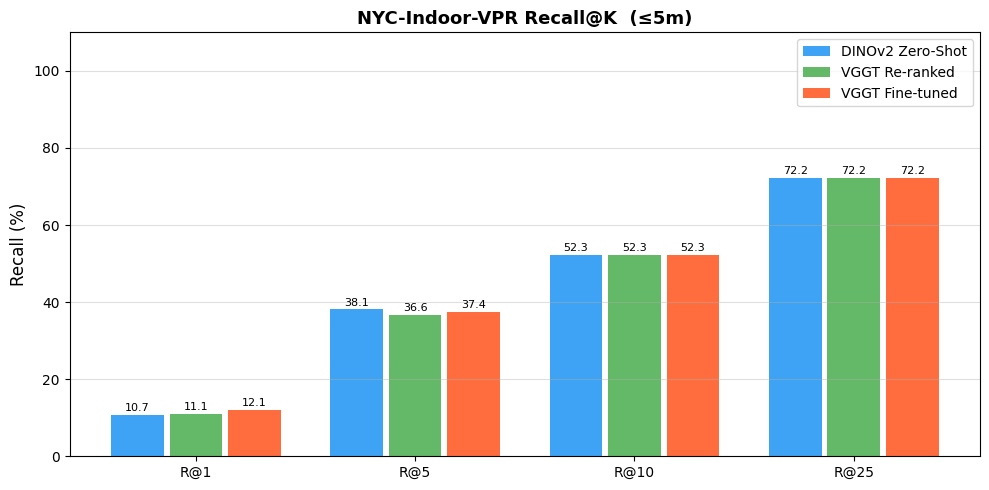

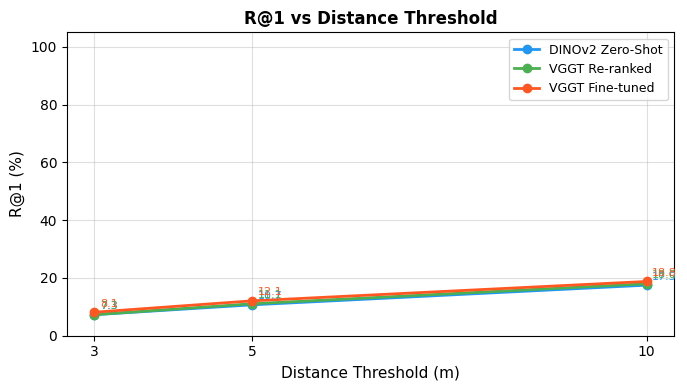

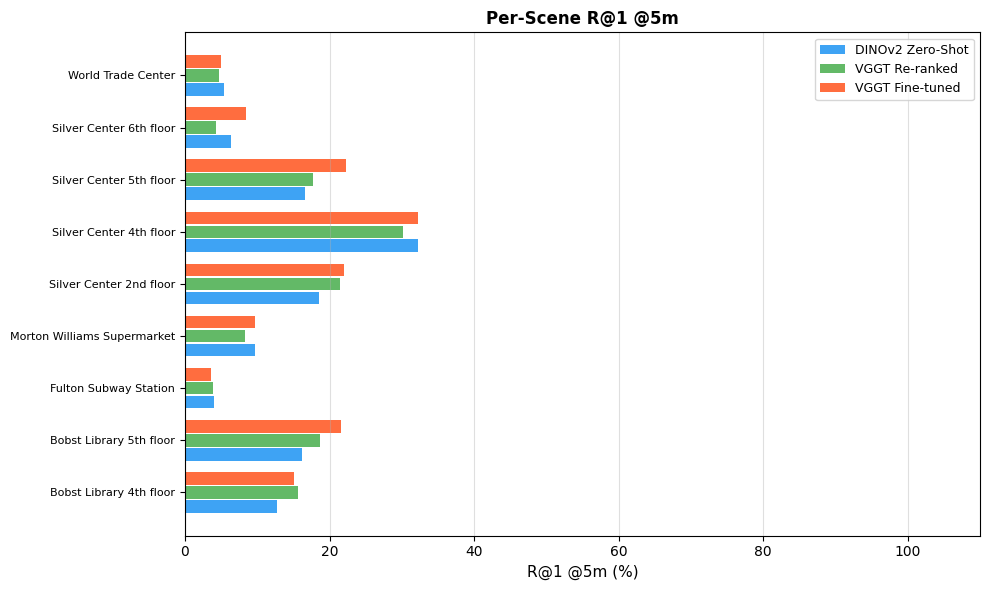

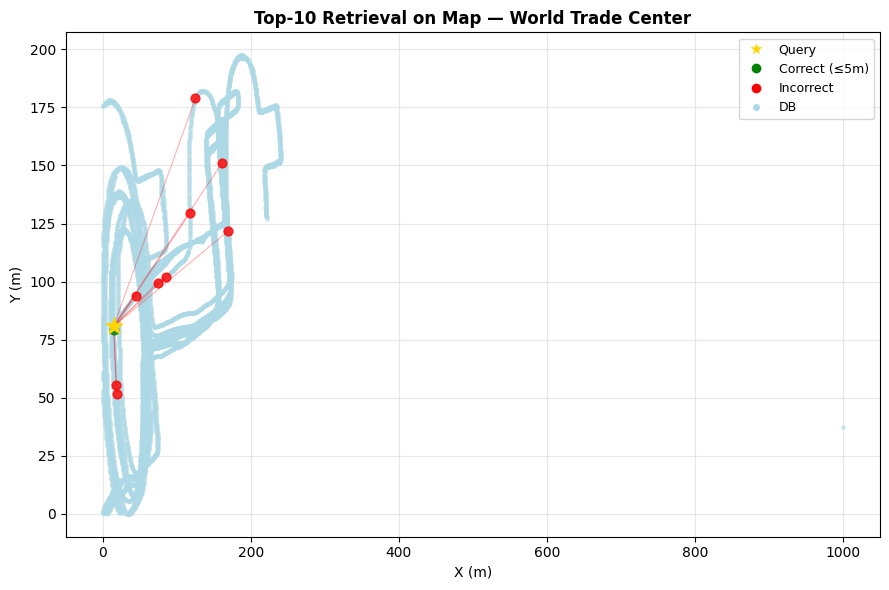

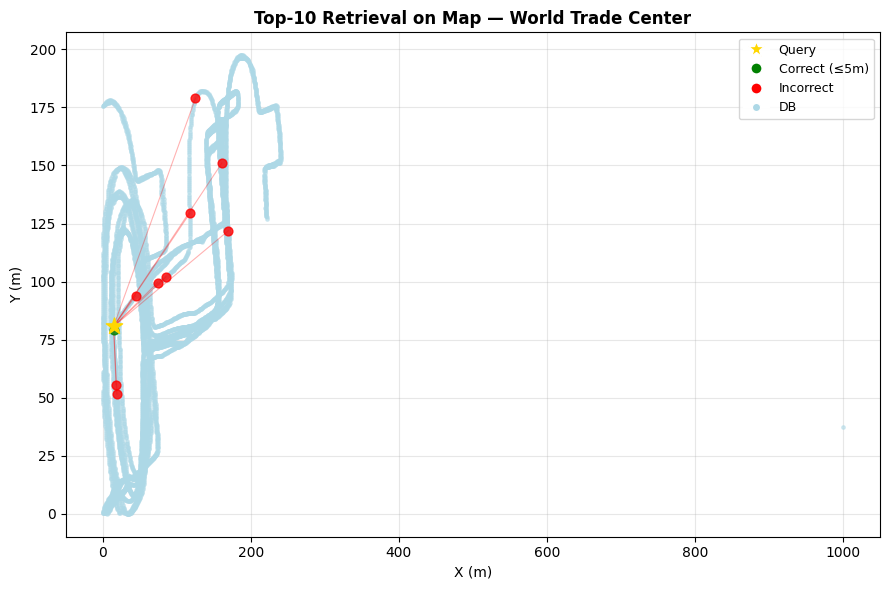

/content/vggt_repo/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


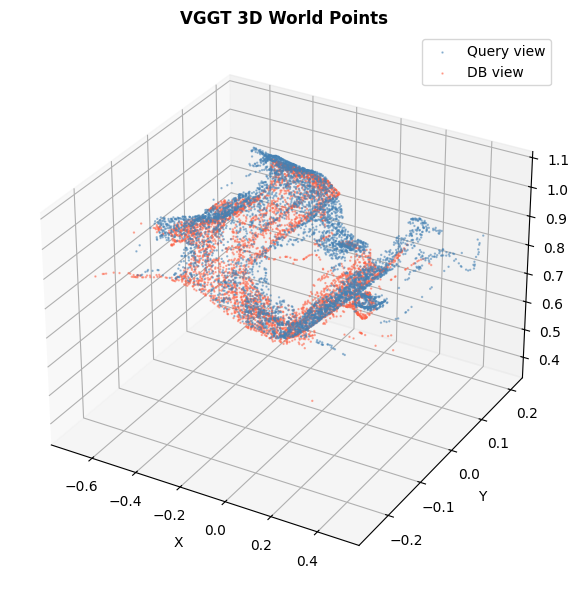

In [37]:
# ── Run all visualizations ────────────────────────────────────────
all_recalls = {
    'DINOv2 Zero-Shot'  : recall_A,
    'VGGT Re-ranked'    : recall_B,
    'VGGT Fine-tuned'   : recall_C
}
all_per_scene = {
    'DINOv2 Zero-Shot'  : per_scene_A,
    'VGGT Re-ranked'    : per_scene_B,
    'VGGT Fine-tuned'   : per_scene_C
}

plot_recall_bars(all_recalls, dist_thresh=5)
plot_recall_vs_threshold(all_recalls, k=1)
plot_per_scene_recall(all_per_scene, k=1, dist_thresh=5)
# plot_training_curves(ft_history)

# Map overlay — World Trade Center (largest scene)
wtc_queries = test_query[test_query['scene']=='World Trade Center']
if len(wtc_queries) > 0:
    q_ex  = wtc_queries.iloc[10]
    q_idx = test_query.reset_index(drop=True).index[
        test_query.reset_index(drop=True)['full_path']==q_ex['full_path']
    ].tolist()[0]
    plot_query_on_map(q_ex, retrieved_A[q_idx], df, k=10,
                      save_path=VIS_DIR/'map_A_WTC.png')
    plot_query_on_map(q_ex, retrieved_B[q_idx], df, k=10,
                      save_path=VIS_DIR/'map_B_WTC.png')

# 3D point cloud visualisation for one matched pair
q_demo  = str(test_query.iloc[0]['full_path'])
db_demo = str(retrieved_A[0][0][0]['full_path'])
plot_pointcloud_pair(q_demo, db_demo)

# Ruuntime Benchmarking

In [38]:
def benchmark_pipeline(query_df, n_samples=30, top_k=25):
    sample = query_df.sample(n_samples, random_state=SEED)
    ret_times, vggt_times = [], []

    for _, q_row in tqdm(sample.iterrows(), total=n_samples, desc='Benchmarking'):
        # Retrieval latency
        t0  = time.perf_counter()
        ret = retrieval_model.retrieve_batch(
                  q_row.to_frame().T.reset_index(drop=True), top_k=top_k)[0]
        ret_times.append((time.perf_counter()-t0)*1000)

        # VGGT re-ranking latency (top-10 only)
        t0 = time.perf_counter()
        for db_row, _ in ret[:10]:
            vggt_geometric_score(str(q_row['full_path']), str(db_row['full_path']))
        vggt_times.append((time.perf_counter()-t0)*1000)

    stats = {
        'retrieval_mean_ms'   : float(np.mean(ret_times)),
        'retrieval_median_ms' : float(np.median(ret_times)),
        'retrieval_p95_ms'    : float(np.percentile(ret_times,95)),
        'vggt_rerank_mean_ms' : float(np.mean(vggt_times)),
        'vggt_rerank_p95_ms'  : float(np.percentile(vggt_times,95)),
        'total_mean_ms'       : float(np.mean(np.array(ret_times)+np.array(vggt_times))),
    }
    print('\n⏱️  Pipeline Latency (per query):')
    for k,v in stats.items(): print(f'  {k}: {v:.1f} ms')
    with open(RESULTS_DIR/'latency.json','w') as f: json.dump(stats,f,indent=2)
    return stats

latency = benchmark_pipeline(test_query)

Query embed: 100%|██████████| 1/1 [00:00<00:00, 15.87it/s]
/content/vggt_repo/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Query embed: 100%|██████████| 1/1 [00:00<00:00, 15.75it/s]
/content/vggt_repo/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Query embed: 100%|██████████| 1/1 [00:00<00:00, 15.55it/s]
/content/vggt_repo/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Query embed: 100%|██████████| 1/1 [00:00<00:00, 15.89it/s]
/content/vggt_repo/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch


⏱️  Pipeline Latency (per query):
  retrieval_mean_ms: 69.7 ms
  retrieval_median_ms: 69.5 ms
  retrieval_p95_ms: 72.0 ms
  vggt_rerank_mean_ms: 2152.5 ms
  vggt_rerank_p95_ms: 2170.8 ms
  total_mean_ms: 2222.2 ms


In [39]:
def print_summary_table(all_recalls):
    w   = 7
    hdr = f"{'Condition':<24} {'Threshold':<12}" + \
          ''.join(f"{'R@'+str(k):>{w}}" for k in K_VALUES)
    sep = '='*len(hdr)
    print('\nNYC-Indoor-VPR — Final Results')
    print(sep); print(hdr)
    for cond, recall in all_recalls.items():
        print('-'*len(hdr))
        for i,d in enumerate(DIST_THRESHOLDS):
            lbl  = cond if i==0 else ''
            vals = ''.join(f"{recall.get(d,{}).get(k,0):>{w}.1f}" for k in K_VALUES)
            print(f"{lbl:<24} ≤{d}m{'':<9}" + vals)
    print(sep)

print_summary_table(all_recalls)


NYC-Indoor-VPR — Final Results
Condition                Threshold       R@1    R@5   R@10   R@25
-----------------------------------------------------------------
DINOv2 Zero-Shot         ≤3m             7.3   26.9   38.2   54.0
                         ≤5m            10.7   38.1   52.3   72.2
                         ≤10m            17.5   54.8   72.7   91.3
-----------------------------------------------------------------
VGGT Re-ranked           ≤3m             7.3   25.6   38.2   54.0
                         ≤5m            11.1   36.6   52.3   72.2
                         ≤10m            18.0   55.2   72.7   91.3
-----------------------------------------------------------------
VGGT Fine-tuned          ≤3m             8.1   26.5   38.2   54.0
                         ≤5m            12.1   37.4   52.3   72.2
                         ≤10m            18.8   55.2   72.7   91.3


In [ ]:
"""
Save All VGGT Results for Future Use
=====================================
Run this cell after your evaluation completes to save everything you need
for future runs without re-running expensive computations.
"""

import pickle
import json
import numpy as np
from pathlib import Path
from google.colab import files

# Create save directory
SAVE_DIR = Path('/content/saved_results')
SAVE_DIR.mkdir(exist_ok=True)

print("📦 Saving all results...\n")

# ============================================================================
# 1. SMALL FILES - Save as JSON (can push to GitHub)
# ============================================================================

print("💾 Saving recall metrics (JSON)...")

# Recall metrics
with open(SAVE_DIR / 'recall_A.json', 'w') as f:
    json.dump({
        'condition': 'DINOv2 Zero-Shot',
        'recall': recall_A,
        'n_queries': len(test_query)
    }, f, indent=2)

with open(SAVE_DIR / 'recall_B.json', 'w') as f:
    json.dump({
        'condition': 'VGGT Re-Ranking',
        'recall': recall_B,
        'n_queries': len(test_query)
    }, f, indent=2)

print("  ✓ recall_A.json")
print("  ✓ recall_B.json")

# Per-scene metrics
print("\n💾 Saving per-scene metrics (JSON)...")
with open(SAVE_DIR / 'per_scene_A.json', 'w') as f:
    json.dump(per_scene_A, f, indent=2)

with open(SAVE_DIR / 'per_scene_B.json', 'w') as f:
    json.dump(per_scene_B, f, indent=2)

print("  ✓ per_scene_A.json")
print("  ✓ per_scene_B.json")

# Metadata
print("\n💾 Saving metadata...")
metadata = {
    'dataset': 'NYC Indoor VPR',
    'num_queries': len(test_query),
    'num_database': len(test_db),
    'top_k': 25,
    'missed_opportunities': 351,  # From your diagnostic
    'test_scenes': test_query['scene'].unique().tolist(),
    'num_test_scenes': test_query['scene'].nunique()
}

with open(SAVE_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("  ✓ metadata.json")

# ============================================================================
# 2. LARGE FILES - Save as pickle (download to local computer)
# ============================================================================

print("\n💾 Saving retrieval lists (pickle - LARGE)...")

# Full retrieval lists (needed for map visualizations)
with open(SAVE_DIR / 'retrieved_A.pkl', 'wb') as f:
    pickle.dump(retrieved_A, f)
print("  ✓ retrieved_A.pkl (~50-100 MB)")

with open(SAVE_DIR / 'retrieved_B.pkl', 'wb') as f:
    pickle.dump(retrieved_B, f)
print("  ✓ retrieved_B.pkl (~50-100 MB)")

# ============================================================================
# 3. COMPRESS AND DOWNLOAD
# ============================================================================

print("\n📦 Compressing files...")
import tarfile

# Small files only (for GitHub)
with tarfile.open(SAVE_DIR / 'results_small.tar.gz', 'w:gz') as tar:
    tar.add(SAVE_DIR / 'recall_A.json', arcname='recall_A.json')
    tar.add(SAVE_DIR / 'recall_B.json', arcname='recall_B.json')
    tar.add(SAVE_DIR / 'per_scene_A.json', arcname='per_scene_A.json')
    tar.add(SAVE_DIR / 'per_scene_B.json', arcname='per_scene_B.json')
    tar.add(SAVE_DIR / 'metadata.json', arcname='metadata.json')

print("  ✓ results_small.tar.gz (~10 KB - for GitHub)")

# Everything including retrieval lists
with tarfile.open(SAVE_DIR / 'results_complete.tar.gz', 'w:gz') as tar:
    tar.add(SAVE_DIR / 'recall_A.json', arcname='recall_A.json')
    tar.add(SAVE_DIR / 'recall_B.json', arcname='recall_B.json')
    tar.add(SAVE_DIR / 'per_scene_A.json', arcname='per_scene_A.json')
    tar.add(SAVE_DIR / 'per_scene_B.json', arcname='per_scene_B.json')
    tar.add(SAVE_DIR / 'metadata.json', arcname='metadata.json')
    tar.add(SAVE_DIR / 'retrieved_A.pkl', arcname='retrieved_A.pkl')
    tar.add(SAVE_DIR / 'retrieved_B.pkl', arcname='retrieved_B.pkl')

print("  ✓ results_complete.tar.gz (~100-200 MB - for local storage)")

# ============================================================================
# 4. DOWNLOAD FILES
# ============================================================================

print("\n📥 Downloading files to your computer...\n")

# Download small files (can push to GitHub)
print("Downloading: results_small.tar.gz (for GitHub)")
files.download(str(SAVE_DIR / 'results_small.tar.gz'))

print("\nDownloading: results_complete.tar.gz (for local storage)")
files.download(str(SAVE_DIR / 'results_complete.tar.gz'))

print("\n" + "="*60)
print("✅ ALL RESULTS SAVED!")
print("="*60)
print("\nWhat you have:")
print("  📁 results_small.tar.gz (~10 KB)")
print("     → Contains: JSON files only")
print("     → Use for: Pushing to GitHub, recreating visualizations")
print("     → Missing: Full retrieval lists (can't make map overlays)")
print()
print("  📁 results_complete.tar.gz (~100-200 MB)")
print("     → Contains: Everything (JSON + pickle files)")
print("     → Use for: Complete restoration of all variables")
print("     → Includes: Full retrieval lists for map visualizations")
print()
print("Save these files on your computer!")
print("="*60)

📦 Saving all results...

💾 Saving recall metrics (JSON)...
  ✓ recall_A.json
  ✓ recall_B.json

💾 Saving per-scene metrics (JSON)...
  ✓ per_scene_A.json
  ✓ per_scene_B.json

💾 Saving metadata...
  ✓ metadata.json

💾 Saving retrieval lists (pickle - LARGE)...
  ✓ retrieved_A.pkl (~50-100 MB)
  ✓ retrieved_B.pkl (~50-100 MB)

📦 Compressing files...
  ✓ results_small.tar.gz (~10 KB - for GitHub)
  ✓ results_complete.tar.gz (~100-200 MB - for local storage)

📥 Downloading files to your computer...

Downloading: results_small.tar.gz (for GitHub)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloading: results_complete.tar.gz (for local storage)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL RESULTS SAVED!

What you have:
  📁 results_small.tar.gz (~10 KB)
     → Contains: JSON files only
     → Use for: Pushing to GitHub, recreating visualizations
     → Missing: Full retrieval lists (can't make map overlays)

  📁 results_complete.tar.gz (~100-200 MB)
     → Contains: Everything (JSON + pickle files)
     → Use for: Complete restoration of all variables
     → Includes: Full retrieval lists for map visualizations

Save these files on your computer!


In [ ]:
"""
Load Saved Results - For Future Colab Sessions
===============================================
Upload your saved files and run this to restore all variables
without re-running the expensive evaluation.
"""

import pickle
import json
import tarfile
from pathlib import Path
from google.colab import files

# ============================================================================
# OPTION 1: Load from tar.gz files (recommended)
# ============================================================================

print("=" * 60)
print("LOAD SAVED RESULTS")
print("=" * 60)

# Upload the tar.gz file
print("\n📤 Upload your saved results file...")
print("Choose one:")
print("  - results_small.tar.gz (for visualizations only)")
print("  - results_complete.tar.gz (includes map overlay data)")
print()

uploaded = files.upload()

# Extract the archive
LOAD_DIR = Path('/content/loaded_results')
LOAD_DIR.mkdir(exist_ok=True)

for filename in uploaded.keys():
    print(f"\n📦 Extracting {filename}...")
    with tarfile.open(filename, 'r:gz') as tar:
        tar.extractall(LOAD_DIR)
    print("  ✓ Extracted")

# ============================================================================
# Load JSON files (always available)
# ============================================================================

print("\n💾 Loading recall metrics...")
with open(LOAD_DIR / 'recall_A.json', 'r') as f:
    data_A = json.load(f)
    recall_A = data_A['recall']
print("  ✓ recall_A loaded")

with open(LOAD_DIR / 'recall_B.json', 'r') as f:
    data_B = json.load(f)
    recall_B = data_B['recall']
print("  ✓ recall_B loaded")

print("\n💾 Loading per-scene metrics...")
with open(LOAD_DIR / 'per_scene_A.json', 'r') as f:
    per_scene_A = json.load(f)
print("  ✓ per_scene_A loaded")

with open(LOAD_DIR / 'per_scene_B.json', 'r') as f:
    per_scene_B = json.load(f)
print("  ✓ per_scene_B loaded")

print("\n💾 Loading metadata...")
with open(LOAD_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)
print("  ✓ metadata loaded")
print(f"     Dataset: {metadata['dataset']}")
print(f"     Queries: {metadata['num_queries']:,}")
print(f"     Database: {metadata['num_database']:,}")

# ============================================================================
# Load pickle files (if available)
# ============================================================================

retrieved_A_available = (LOAD_DIR / 'retrieved_A.pkl').exists()
retrieved_B_available = (LOAD_DIR / 'retrieved_B.pkl').exists()

if retrieved_A_available and retrieved_B_available:
    print("\n💾 Loading retrieval lists...")
    with open(LOAD_DIR / 'retrieved_A.pkl', 'rb') as f:
        retrieved_A = pickle.load(f)
    print("  ✓ retrieved_A loaded")

    with open(LOAD_DIR / 'retrieved_B.pkl', 'rb') as f:
        retrieved_B = pickle.load(f)
    print("  ✓ retrieved_B loaded")
else:
    print("\n⚠️  Retrieval lists not available")
    print("   (You uploaded results_small.tar.gz)")
    print("   → Can create comparison charts")
    print("   → Cannot create map overlays")

# ============================================================================
# Define constants
# ============================================================================

K_VALUES = [1, 5, 10, 25]
DIST_THRESHOLDS = [3, 5, 10]

print("\n" + "=" * 60)
print("✅ LOADING COMPLETE!")
print("=" * 60)

print("\n📊 Available variables:")
print("  ✓ recall_A, recall_B")
print("  ✓ per_scene_A, per_scene_B")
print("  ✓ metadata")
print("  ✓ K_VALUES, DIST_THRESHOLDS")

if retrieved_A_available and retrieved_B_available:
    print("  ✓ retrieved_A, retrieved_B")
else:
    print("  ✗ retrieved_A, retrieved_B (not loaded)")

print("\n🎨 You can now run:")
print("  - plot_recall_bars()")
print("  - plot_recall_vs_threshold()")
print("  - plot_per_scene_recall()")

if retrieved_A_available and retrieved_B_available:
    print("  - plot_query_on_map() [requires test_query, df]")
else:
    print("  - plot_query_on_map() [NOT AVAILABLE - need retrieved_A/B]")

print("=" * 60)


# ============================================================================
# OPTION 2: Quick load from individual files (alternative method)
# ============================================================================

"""
If you prefer to upload individual JSON files instead:

# Upload files
uploaded = files.upload()  # Upload recall_A.json, recall_B.json, etc.

# Load them
import json
with open('recall_A.json', 'r') as f:
    recall_A = json.load(f)['recall']

with open('recall_B.json', 'r') as f:
    recall_B = json.load(f)['recall']

# etc.
"""

LOAD SAVED RESULTS

📤 Upload your saved results file...
Choose one:
  - results_small.tar.gz (for visualizations only)
  - results_complete.tar.gz (includes map overlay data)



Saving results_complete.tar.gz to results_complete.tar.gz

📦 Extracting results_complete.tar.gz...
  ✓ Extracted

💾 Loading recall metrics...
  ✓ recall_A loaded
  ✓ recall_B loaded

💾 Loading per-scene metrics...
  ✓ per_scene_A loaded
  ✓ per_scene_B loaded

💾 Loading metadata...
  ✓ metadata loaded
     Dataset: NYC Indoor VPR
     Queries: 1,880
     Database: 1,939

💾 Loading retrieval lists...


/tmp/ipykernel_13746/438615590.py:38: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(LOAD_DIR)


  ✓ retrieved_A loaded
  ✓ retrieved_B loaded

✅ LOADING COMPLETE!

📊 Available variables:
  ✓ recall_A, recall_B
  ✓ per_scene_A, per_scene_B
  ✓ metadata
  ✓ K_VALUES, DIST_THRESHOLDS
  ✓ retrieved_A, retrieved_B

🎨 You can now run:
  - plot_recall_bars()
  - plot_recall_vs_threshold()
  - plot_per_scene_recall()
  - plot_query_on_map() [requires test_query, df]


"\nIf you prefer to upload individual JSON files instead:\n\n# Upload files\nuploaded = files.upload()  # Upload recall_A.json, recall_B.json, etc.\n\n# Load them\nimport json\nwith open('recall_A.json', 'r') as f:\n    recall_A = json.load(f)['recall']\n    \nwith open('recall_B.json', 'r') as f:\n    recall_B = json.load(f)['recall']\n    \n# etc.\n"